# Actividad 1: Arquitectura de Redes Neuronales

## Dataset Sonar

El objetivo es clasificar una señal de sonar como **piedra (R)** o **mina (M)** usando una red neuronal.

## 1. Análisis exploratorio de datos

El archivo no tiene nombres de columnas. Las primeras 60 columnas son señales de entrada y la última columna es la clase:

- `R`: piedra.
- `M`: mina.

In [31]:
# Importar módulos
import time
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para el preprocesamiento y la evaluación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
# Cargar el dataset
sonar = pd.read_csv('sonar data.csv', header=None)


columnas = [f'frecuencia_{i}' for i in range(1, 61)] + ['clase']
sonar.columns = columnas

print(f'Tamaño del dataset: {sonar.shape}')
sonar.head()

Tamaño del dataset: (208, 61)


,frecuencia_1,frecuencia_2,frecuencia_3,frecuencia_4,frecuencia_5,frecuencia_6,frecuencia_7,frecuencia_8,frecuencia_9,frecuencia_10,...,frecuencia_52,frecuencia_53,frecuencia_54,frecuencia_55,frecuencia_56,frecuencia_57,frecuencia_58,frecuencia_59,frecuencia_60,clase
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


### Revisión general

In [18]:
# Estadísticas básicas de las variables numéricas
sonar.describe()

,frecuencia_1,frecuencia_2,frecuencia_3,frecuencia_4,frecuencia_5,frecuencia_6,frecuencia_7,frecuencia_8,frecuencia_9,frecuencia_10,...,frecuencia_51,frecuencia_52,frecuencia_53,frecuencia_54,frecuencia_55,frecuencia_56,frecuencia_57,frecuencia_58,frecuencia_59,frecuencia_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [19]:
# Verificar espacios en blanco, valores NaN y filas duplicadas
print('Valores NaN por columna:')
print(sonar.isnull().sum().sum())
print('Filas duplicadas:', sonar.duplicated().sum())
print('Clases encontradas:', sonar['clase'].unique())
print('Tipos de datos:')
print(sonar.dtypes.value_counts())

Valores NaN por columna:
0
Filas duplicadas: 0
Clases encontradas: <StringArray>
['R', 'M']
Length: 2, dtype: str
Tipos de datos:
float64    60
str         1
Name: count, dtype: int64


In [20]:
# Revisar el rango de las señales
entradas = sonar.drop('clase', axis=1)
print('Valor mínimo:', entradas.min().min())
print('Valor máximo:', entradas.max().max())
print('Valores no numéricos:', entradas.apply(pd.to_numeric, errors='coerce').isnull().sum().sum())

Valor mínimo: 0.0
Valor máximo: 1.0
Valores no numéricos: 0


clase
M    111
R     97
Name: count, dtype: int64
Porcentajes:
clase
M    53.37
R    46.63
Name: proportion, dtype: float64


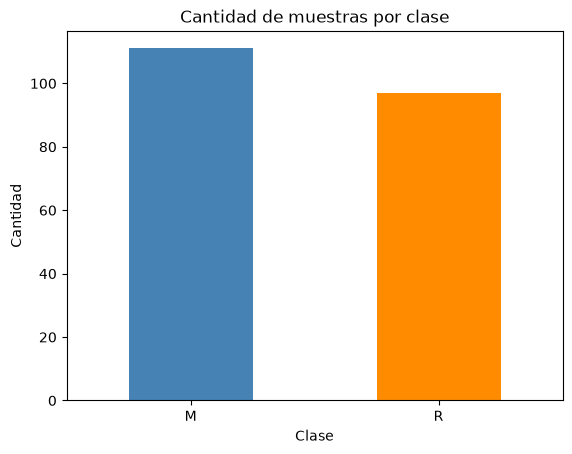

In [21]:
# Revisar si el dataset está balanceado
conteo_clases = sonar['clase'].value_counts()
porcentaje_clases = sonar['clase'].value_counts(normalize=True).mul(100).round(2)

print(conteo_clases)
print('Porcentajes:')
print(porcentaje_clases)

conteo_clases.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Cantidad de muestras por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

**Resultado del balance:** hay 111 muestras de minas (M) y 97 de piedras (R). La distribución es aproximadamente 53.37% y 46.63%, por lo que el dataset está suficientemente equilibrado, aunque no es perfectamente 50/50.

Posibles valores outlier: 325
Filas con al menos un posible outlier: 74
Variables con al menos un posible outlier: 39


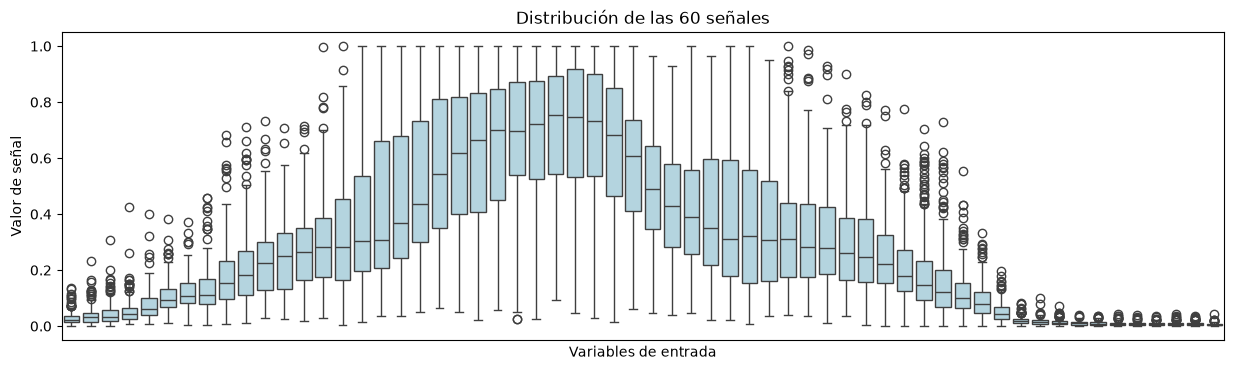

In [22]:
# Detectar posibles outliers usando el rango intercuartílico (IQR)
Q1 = entradas.quantile(0.25)
Q3 = entradas.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
mascara_outliers = (entradas.lt(limite_inferior, axis=1) | entradas.gt(limite_superior, axis=1))

print('Posibles valores outlier:', mascara_outliers.sum().sum())
print('Filas con al menos un posible outlier:', mascara_outliers.any(axis=1).sum())
print('Variables con al menos un posible outlier:', mascara_outliers.any(axis=0).sum())

# Boxplot simple para observar la dispersión de las señales
plt.figure(figsize=(15, 4))
sns.boxplot(data=entradas, color='lightblue')
plt.title('Distribución de las 60 señales')
plt.xlabel('Variables de entrada')
plt.ylabel('Valor de señal')
plt.xticks([])
plt.show()

El criterio IQR puede marcar valores alejados del centro, pero no significa que sean errores. En este dataset las señales están dentro del rango válido 0 a 1, no hay NaN, no hay duplicados y no se observan valores imposibles. Por eso no se eliminan automáticamente los posibles outliers.

## 2. Preprocesamiento

Se separan las entradas `X` y la salida `y`. La clase se transforma a números:

- `R` se transforma en 0.
- `M` se transforma en 1.

Después se separan los datos en entrenamiento y testeo usando una división 75/25 y manteniendo la proporción de clases.

In [23]:
# Separar X e y
X = sonar.drop('clase', axis=1).values.astype('float32')
y = sonar['clase'].map({'R': 0, 'M': 1}).values.astype('float32')

print(f'Conjunto X: {X.shape}')
print(f'Conjunto y: {y.shape}')

# Separar entrenamiento y testeo
X_e, X_t, y_e, y_t = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=40
)

print(f'X_e: {X_e.shape} - y_e: {y_e.shape}')
print(f'X_t: {X_t.shape} - y_t: {y_t.shape}')

Conjunto X: (208, 60)
Conjunto y: (208,)
X_e: (156, 60) - y_e: (156,)
X_t: (52, 60) - y_t: (52,)


In [24]:
# Estandarizar usando solamente el conjunto de entrenamiento
escalador = StandardScaler()
X_e = escalador.fit_transform(X_e)
X_t = escalador.transform(X_t)

print('Promedio aproximado de X_e:', X_e.mean().round(4))
print('Desviación estándar aproximada de X_e:', X_e.std().round(4))

Promedio aproximado de X_e: -0.0
Desviación estándar aproximada de X_e: 1.0


## 3. Diseño de la arquitectura

Se propone una red pequeña, suficiente para un dataset de solo 208 observaciones:

- Entrada: 60 neuronas, una por cada señal.
- Primera capa oculta: 32 neuronas con activación ReLU.
- Segunda capa oculta: 16 neuronas con activación ReLU.
- Dropout de 20% para ayudar a reducir el sobreajuste.
- Salida: 1 neurona con activación sigmoide, porque se trata de una clasificación binaria.
- Función de pérdida: `binary_crossentropy`.
- Solver/optimizador: Adam con ratio de aprendizaje 0.001.
- Métrica principal: accuracy.

## 4. Implementación con Keras/TensorFlow

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Dejar resultados reproducibles
np.random.seed(40)
tf.random.set_seed(40)

modelo = keras.Sequential([
    layers.Input(shape=(60,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.20),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento y tiempo de ejecución

Se entrenará durante 200 épocas, con lotes de 16 observaciones. El conjunto de test se usa como conjunto de validación para visualizar su evolución.

In [26]:
# Información de la máquina de entrenamiento
print('Sistema operativo:', platform.platform())
print('Procesador:', platform.processor())
print('Versión de Python:', platform.python_version())
print('Versión de TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

# Entrenamiento y medición del tiempo
inicio = time.perf_counter()

historial = modelo.fit(
    X_e,
    y_e,
    epochs=200,
    batch_size=16,
    validation_data=(X_t, y_t),
    verbose=0
)

fin = time.perf_counter()
print(f'Tiempo de entrenamiento: {fin - inicio:.2f} segundos')

Sistema operativo: Windows-11-10.0.26200-SP0
Procesador: AMD64 Family 25 Model 33 Stepping 0, AuthenticAMD
Versión de Python: 3.12.10
Versión de TensorFlow: 2.21.0
GPU disponible: []
Tiempo de entrenamiento: 15.34 segundos


## 6. Evaluación del modelo

Se visualiza la evolución de la pérdida y de la precisión para entrenamiento y testeo. Luego se calcula la matriz de confusión y el reporte de clasificación.

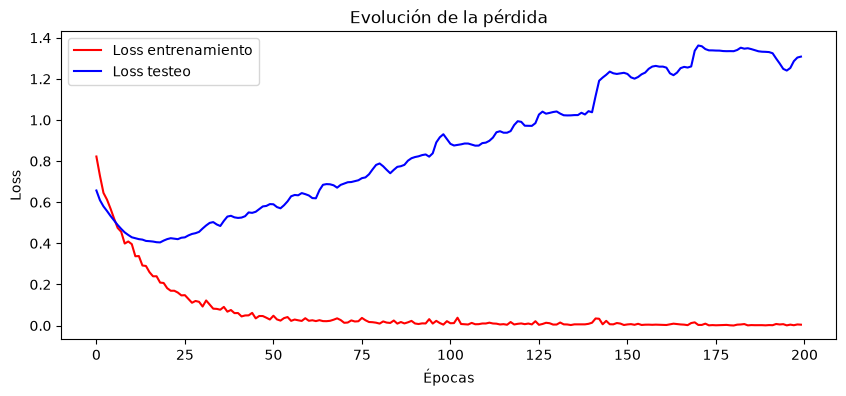

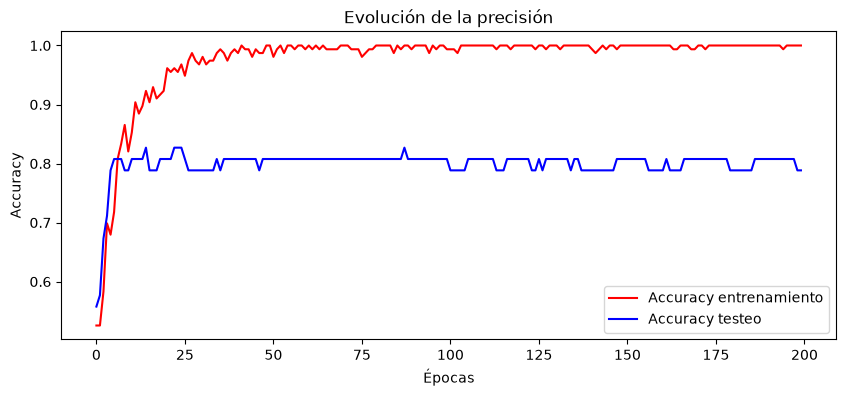

In [27]:
# Evolución de la pérdida
plt.figure(figsize=(10, 4))
plt.plot(historial.history['loss'], 'r', label='Loss entrenamiento')
plt.plot(historial.history['val_loss'], 'b', label='Loss testeo')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evolución de la precisión
plt.figure(figsize=(10, 4))
plt.plot(historial.history['accuracy'], 'r', label='Accuracy entrenamiento')
plt.plot(historial.history['val_accuracy'], 'b', label='Accuracy testeo')
plt.title('Evolución de la precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
# Evaluación final en entrenamiento y testeo
perdida_e, precision_e = modelo.evaluate(X_e, y_e, verbose=0)
perdida_t, precision_t = modelo.evaluate(X_t, y_t, verbose=0)

print(f'Precisión entrenamiento: {precision_e * 100:.2f}%')
print(f'Precisión testeo: {precision_t * 100:.2f}%')
print(f'Pérdida entrenamiento: {perdida_e:.4f}')
print(f'Pérdida testeo: {perdida_t:.4f}')

Precisión entrenamiento: 100.00%
Precisión testeo: 78.85%
Pérdida entrenamiento: 0.0003
Pérdida testeo: 1.3082


In [29]:
# Predicciones y matriz de confusión
probabilidades = modelo.predict(X_t, verbose=0)
predicciones = (probabilidades >= 0.5).astype(int).ravel()

print('Accuracy calculada:', accuracy_score(y_t, predicciones))
print('Matriz de confusión:')
print(confusion_matrix(y_t, predicciones))
print('Reporte de clasificación:')
print(classification_report(y_t, predicciones, target_names=['R - Piedra', 'M - Mina']))

Accuracy calculada: 0.7884615384615384
Matriz de confusión:
[[18  6]
 [ 5 23]]
Reporte de clasificación:
              precision    recall  f1-score   support

  R - Piedra       0.78      0.75      0.77        24
    M - Mina       0.79      0.82      0.81        28

    accuracy                           0.79        52
   macro avg       0.79      0.79      0.79        52
weighted avg       0.79      0.79      0.79        52



## 7. Análisis de resultados

El valor final de accuracy de testeo se obtiene en la celda anterior. Como referencia, una precisión cercana o superior al 80% representa una mejora importante frente al clasificador básico de aproximadamente 53%, y se acerca al rango esperado para este dataset.

La arquitectura se considera generalizable si la precisión de testeo es alta y no existe una diferencia excesiva entre entrenamiento y testeo. La siguiente celda entrega una conclusión automática usando una diferencia máxima de 10 puntos porcentuales.

In [30]:
diferencia = abs(precision_e - precision_t)
print(f'Diferencia entre entrenamiento y testeo: {diferencia * 100:.2f} puntos porcentuales')

if precision_t >= 0.80 and diferencia <= 0.10:
    print('Conclusión: el modelo logra una precisión esperada y muestra una generalización razonable.')
elif precision_t >= 0.80:
    print('Conclusión: el modelo logra una precisión esperada, pero presenta señales de sobreajuste.')
else:
    print('Conclusión: el modelo todavía no alcanza la precisión esperada y se podría ajustar la arquitectura o los hiperparámetros.')

Diferencia entre entrenamiento y testeo: 21.15 puntos porcentuales
Conclusión: el modelo todavía no alcanza la precisión esperada y se podría ajustar la arquitectura o los hiperparámetros.
